Visually, we saw that in the actual data, we can broadly categorize perturbation shifts into three categories:

1) Diverging -- origin (start) perturbation cell-subtype-centroids are closer together than target (end) perturbation centroids
2) Converging -- origin (start) perturbation cell-subtype-centroids are farther apart than target (end) perturbation centroids
3) Parallel -- expression shifts are similar for each subtype


These are important because they have different expectations for the counterfactual, or how the model is able to transition from the input perturbation to the output one. In other words, is the subtype heterogeneity of the target maintained regardless of the relative heterogeneity of the origin?

In [1]:
import os
import joblib

import pandas as pd
import numpy as np
import scanpy as sc

import torch 

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
import seaborn as sns

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
import scLEMBAS.utilities as utils
from scLEMBAS.predict import get_prediction

sys.path.insert(1, '../../.')
from McCauley_utils import all_data, initialize_mod_and_trainer

sys.path.insert(1, '../../../.') 
from notebook_utils import get_split, clear_adata


/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/orcd/pool/005/hmbaghda/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/us

In [2]:
seed = 888
data_path = '/home/hmbaghda/orcd/pool/scLEMBAS/analysis'
author = 'McCauley'

n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(1)
os.environ["MKL_NUM_THREADS"] = str(1)
os.environ["OPENBLAS_NUM_THREADS"] = str(1)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(1)
os.environ["NUMEXPR_NUM_THREADS"] = str(1)


In [3]:
(sn_ppis, tf_adata, adata, expr, source_label, target_label, weight_label, 
 stimulation_label, inhibition_label, cat_col, pert_col, ctrl_pert) = all_data


tf_adata.obs['barcodes'] = tf_adata.obs.index.tolist()

pls_models = joblib.load(os.path.join(data_path, 'processed', 'cellsubtype_pls_models_pert.joblib'))
pls_models_ctrl = joblib.load(os.path.join(data_path, 'processed', 'cellsubtype_pls_models.joblib'))
for k, pls_model in pls_models_ctrl.items():
    ct, target_pert = k.split('^')
    cond_label = ct + '^' + ctrl_pert + '->' + target_pert
    pls_models[cond_label] = pls_model
    
del pls_models_ctrl

In [4]:
def add_pls(pls_model, adata):
    adata.uns['pls'] = {'pls_mod': pls_model}
    adata.obsm['X_pls'] = pls_model.transform(adata.X)
    return adata

def order_transition_first(lst):
    return sorted(lst, key=lambda x: 'transition' not in x.lower())

# Forward Pass:

In [5]:
def get_substype_prediction(
    ct: str, 
    origin_pert: str, 
    target_pert: str, 
    include_origin_actual: bool = False
):
    
    """Gets the predictions for the subtypes specified for a given cell type, origin perturbation and target perturbation. 

    Parameters
    ----------
    ct : str
        cell type
    origin_pert : str
        starting perturbation
        together with `ct`, defines the input gene expression vectors for the counterfactual
    target_pert : str
        ending perturbation
        together with `ct`, defines the output predictions from the counterfactual
    include_origin_actual : bool, optional
        whether to include the actual data origin perturbations in the predicted anndata object, by default False
    """
    
    # get conditions subsets
    ct_mask = (tf_adata.obs[cat_col] == ct)
    pert_mask = (tf_adata.obs[pert_col].isin([origin_pert, target_pert]))
    tf_adata_actual = tf_adata[ct_mask & pert_mask].copy()
    tf_adata_actual = clear_adata(tf_adata_actual)

    cell_subtypes = tf_adata_actual.obs.secretory_mcc_subsets.unique()
    cell_subtypes = order_transition_first(cell_subtypes)

    ######################## get folds that have origin perturbation in training and target perturbation in test ########################
    working_folds = []
    for fold in range(5):
        split = get_split(fold = fold, author = author)

        a = '^'.join([ct, origin_pert]) in split['train_conds']
        b = '^'.join([ct, target_pert]) in split['test_conds']

        if a and b:
            working_folds.append(fold)
    assert len(working_folds) > 0, 'No folds have the origin perturbation in train and target perturbtion in test'
    assert len(working_folds) == 1, 'Need to deal with multiple folds having this option'
    fold = working_folds[0]

    fn_trainer = os.path.join(data_path, 'processed', '{}_fold{}trainer_actual.pickle'.format(author, fold))
    trainer = io.read_pickled_object(fn_trainer)
    mod = trainer.mod

    split = get_split(fold = fold, author = author)

    train_barcodes = split['train_barcodes']
    test_barcodes = split['test_barcodes']

    assert trainer.X_train.index.tolist() == train_barcodes, 'Train barcodes mismatch'
    assert trainer.X_test.index.tolist() == test_barcodes, 'Test barcodes mismatch'


    ######################## subset to conditions of interest ########################
    train_mask = (tf_adata.obs['barcodes'].isin(train_barcodes)) & \
    (tf_adata.obs.condition == '^'.join([ct, origin_pert]))

    test_mask = (tf_adata.obs['barcodes'].isin(test_barcodes)) & \
    (tf_adata.obs.condition == '^'.join([ct, target_pert]))

    cst_mask = (tf_adata.obs['secretory_mcc_subsets'] == cell_subtypes[0])

    ######################## PREDICT EACH SUBTYPE SEPARATELY ########################

    # subtype 1
    tf_adata_predicted_0 = get_prediction(
        mod = mod,
        train_cells = tf_adata[train_mask & cst_mask].obs.barcodes.tolist(),
        test_cells = tf_adata[test_mask].obs.barcodes.tolist(), 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col,
        ctrl_pert = ctrl_pert, 
        counterfactual = 'perturbation', # counterfactual from tests
        cat_counterfactual_map = None,
        remove_type = 'none',
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False, 
        stim_label_map = None, # special use case for Kang
        predict_from_pert = origin_pert if origin_pert != ctrl_pert else None, # not predicting from control
    )
    tf_adata_predicted_0.obs['secretory_mcc_subsets'] = cell_subtypes[0]

    # subtype 2
    tf_adata_predicted_1 = get_prediction(
        mod = mod,
        train_cells = tf_adata[train_mask & ~cst_mask].obs.barcodes.tolist(),
        test_cells = tf_adata[test_mask].obs.barcodes.tolist(), 
        tf_adata = tf_adata,
        cat_col = cat_col,
        pert_col = pert_col,
        ctrl_pert = ctrl_pert, 
        counterfactual = 'perturbation', # counterfactual from tests
        cat_counterfactual_map = None,
        remove_type = 'none',
        return_bias = False, 
        max_cells = int(5e3), 
        return_full = False, 
        stim_label_map = None, # special use case for Kang
        predict_from_pert = origin_pert, # not predicting from control
    )
    tf_adata_predicted_1.obs['secretory_mcc_subsets'] = cell_subtypes[1]
    tf_adata_predicted = sc.concat([tf_adata_predicted_0, tf_adata_predicted_1])
    del tf_adata_predicted_0, tf_adata_predicted_1

    ######################## Formatting ########################
    # annotate with data type
    tf_adata_predicted.obs['batch'] = 'predicted'
    tf_adata_actual.obs['batch'] = 'actual'


    # add acutal origin pert to predicted for visualization
    if include_origin_actual:
        tf_adata_predicted = sc.concat([
            tf_adata_actual[tf_adata_actual.obs[pert_col] == origin_pert], 
            tf_adata_predicted
        ])

    # categorial
    for adata_obj in [tf_adata_predicted, tf_adata_actual]:
        adata_obj.obs['secretory_mcc_subsets'] = pd.Categorical(
            adata_obj.obs['secretory_mcc_subsets'], categories = cell_subtypes, ordered = True
        )

        adata_obj.obs[pert_col] = pd.Categorical(
            adata_obj.obs[pert_col], categories = [origin_pert, target_pert], ordered = True
        )

    # # add pls models
    pls_model = pls_models[ct + '^' + origin_pert + '->' + target_pert]
    tf_adata_predicted = add_pls(pls_model, tf_adata_predicted)
    tf_adata_actual = add_pls(pls_model, tf_adata_actual)

    return tf_adata_actual, tf_adata_predicted

In [6]:
from typing import Literal
def prep_viz_df(
    adata, 
    viz_type: Literal['prediction', 'actual'], 
    include_origin_actual: bool
):

    viz_df = pd.DataFrame(
        adata.obsm['X_pls'], 
        index = adata.obs_names, 
        columns = ['PLS{}'.format(i+1) for i in range(adata.obsm['X_pls'].shape[1])]
    )
    for col in [cat_col, 'secretory_mcc_subsets', pert_col, 'batch']:
        viz_df[col] = adata.obs[col].copy()

    # sanity checks
    if viz_type == 'prediction':
        adata_pred_pert = viz_df[viz_df.batch == 'predicted'].ligand.unique().tolist()
        adata_origin_pert = viz_df[viz_df.batch == 'actual'].ligand.unique().tolist()

        a = len(adata_pred_pert) == 1
        b = (len(adata_origin_pert) == 1) if include_origin_actual else (len(adata_origin_pert) == 0)
        assert a and b, 'Incorrect mapping of prediction'

        a = adata_pred_pert[0] == target_pert
        b = (adata_origin_pert[0] == origin_pert) if include_origin_actual else (adata_origin_pert == [])
        assert a and b, 'Incorrect mapping of prediction'
    else:
        assert viz_df['batch'].unique().tolist() == ['actual'], 'Incorrect actual data'
        assert viz_df[pert_col].nunique() == 2, 'Incorrect actual data'
    viz_df.drop(columns = ['batch'], inplace = True)
    
    return viz_df
    

In [7]:
def plot_panel(viz_df, ax, cond_, n_scatter, origin_pert):

    pls_cols = [c for c in viz_df.columns if c not in ['secretory_mcc_subsets', pert_col]]
    x_col, y_col = pls_cols[:2]

    viz_df_ = viz_df.copy()

    viz_df_['subtype_plot'] = np.where(
        viz_df_['secretory_mcc_subsets'].str.contains('transitional', case=False, na=False),
        'Transitional',
        'Mature'
    )

    viz_df_['pert_plot'] = np.where(
        viz_df_[pert_col] == origin_pert,
        'Origin',
        'Target'
    )

    cond_order = [
        'Transitional | Origin',
        'Mature | Origin',
        'Transitional | Target',
        'Mature | Target'
    ]

    subtype_palette = {
        'Transitional': '#66c2ff',
        'Mature': '#f4a261'
    }

    pert_linestyle = {
        'Origin': 'solid',
        'Target': 'dashed'
    }

    pert_marker = {
        'Origin': 'o',
        'Target': '^'
    }

    for cond in cond_order:
        subtype, pert_status = cond.split(' | ')
        sub_df = viz_df_[
            (viz_df_['subtype_plot'] == subtype) &
            (viz_df_['pert_plot'] == pert_status)
        ]

        if sub_df.shape[0] > n_scatter:
            sns.kdeplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                fill=False,
                levels=5,
                color=subtype_palette[subtype],
                linestyles=pert_linestyle[pert_status]
            )
        else:
            sns.scatterplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                color=subtype_palette[subtype],
                marker=pert_marker[pert_status],
                s=40
            )

    legend_handles = [
        Patch(facecolor=subtype_palette['Transitional'], label='Transitional'),
        Patch(facecolor=subtype_palette['Mature'], label='Mature'),
        Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Origin (KDE)'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Target (KDE)'),
        Line2D([0], [0], marker='o', linestyle='', color='black', label='Origin (scatter)'),
        Line2D([0], [0], marker='^', linestyle='', color='black', label='Target (scatter)')
    ]

    ax.legend(handles=legend_handles, title='Subtype / Condition', ncol=3)
    ax.set_title(': '.join(cond_.split('^')))




In [8]:
def darken_color(color, factor=0.65):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))


def plot_panel(viz_df, ax, cond_, n_scatter, origin_pert, display_vectors=False):

    pls_cols = [c for c in viz_df.columns if c not in ['secretory_mcc_subsets', pert_col]]
    x_col, y_col = pls_cols[:2]

    viz_df_ = viz_df.copy()

    viz_df_['subtype_plot'] = np.where(
        viz_df_['secretory_mcc_subsets'].str.contains('transitional', case=False, na=False),
        'Transitional',
        'Mature'
    )

    viz_df_['pert_plot'] = np.where(
        viz_df_[pert_col] == origin_pert,
        'Origin',
        'Divergent'
    )

    cond_order = [
        'Transitional | Origin',
        'Mature | Origin',
        'Transitional | Divergent',
        'Mature | Divergent'
    ]

    subtype_palette = {
        'Transitional': '#66c2ff',
        'Mature': '#f4a261'
    }

    pert_linestyle = {
        'Origin': 'solid',
        'Divergent': 'dashed'
    }

    pert_marker = {
        'Origin': 'o',
        'Divergent': '^'
    }

    for cond in cond_order:
        subtype, pert_status = cond.split(' | ')
        sub_df = viz_df_[
            (viz_df_['subtype_plot'] == subtype) &
            (viz_df_['pert_plot'] == pert_status)
        ]

        if sub_df.shape[0] > n_scatter:
            sns.kdeplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                fill=False,
                levels=5,
                color=subtype_palette[subtype],
                linestyles=pert_linestyle[pert_status]
            )
        else:
            sns.scatterplot(
                data=sub_df,
                x=x_col,
                y=y_col,
                ax=ax,
                color=subtype_palette[subtype],
                marker=pert_marker[pert_status],
                s=40
            )

    if display_vectors:
        for subtype in ['Transitional', 'Mature']:

            origin_df = viz_df_[
                (viz_df_['subtype_plot'] == subtype) &
                (viz_df_['pert_plot'] == 'Origin')
            ]

            target_df = viz_df_[
                (viz_df_['subtype_plot'] == subtype) &
                (viz_df_['pert_plot'] == 'Divergent')
            ]

            if len(origin_df) == 0 or len(target_df) == 0:
                continue

            origin_centroid = origin_df[[x_col, y_col]].mean().values
            target_centroid = target_df[[x_col, y_col]].mean().values

            arrow_color = darken_color(subtype_palette[subtype], factor=0.65)

            ax.annotate(
                '',
                xy=target_centroid,
                xytext=origin_centroid,
                arrowprops=dict(
                    arrowstyle='-|>',
                    color=arrow_color,
                    lw=4.0,
                    mutation_scale=24,
                    shrinkA=0,
                    shrinkB=0
                ),
                zorder=6
            )

    legend_handles = [
        Patch(facecolor=subtype_palette['Transitional'], label='Transitional'),
        Patch(facecolor=subtype_palette['Mature'], label='Mature'),
        Line2D([0], [0], color='black', lw=2, linestyle='solid', label='Origin'),
        Line2D([0], [0], color='black', lw=2, linestyle='dashed', label='Divergent'),
        Line2D([0], [0], marker='o', linestyle='', color='black', label='Origin (scatter)'),
        Line2D([0], [0], marker='^', linestyle='', color='black', label='Divergent (scatter)')
    ]

    ax.legend(handles=legend_handles, title='Subtype / Condition', ncol=3)
    ax.set_title(': '.join(cond_.split('^')))

In [9]:
sns.set_context(
    "paper",
    rc={
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "legend.fontsize": 10,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
    }
)

Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.75it/s]


Get the predictions
Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.34it/s]

Get the predictions


...

Get the predictions


Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.08it/s]

Get the predictions


Text(0.5, 0.98, 'Divergent Case Examples')

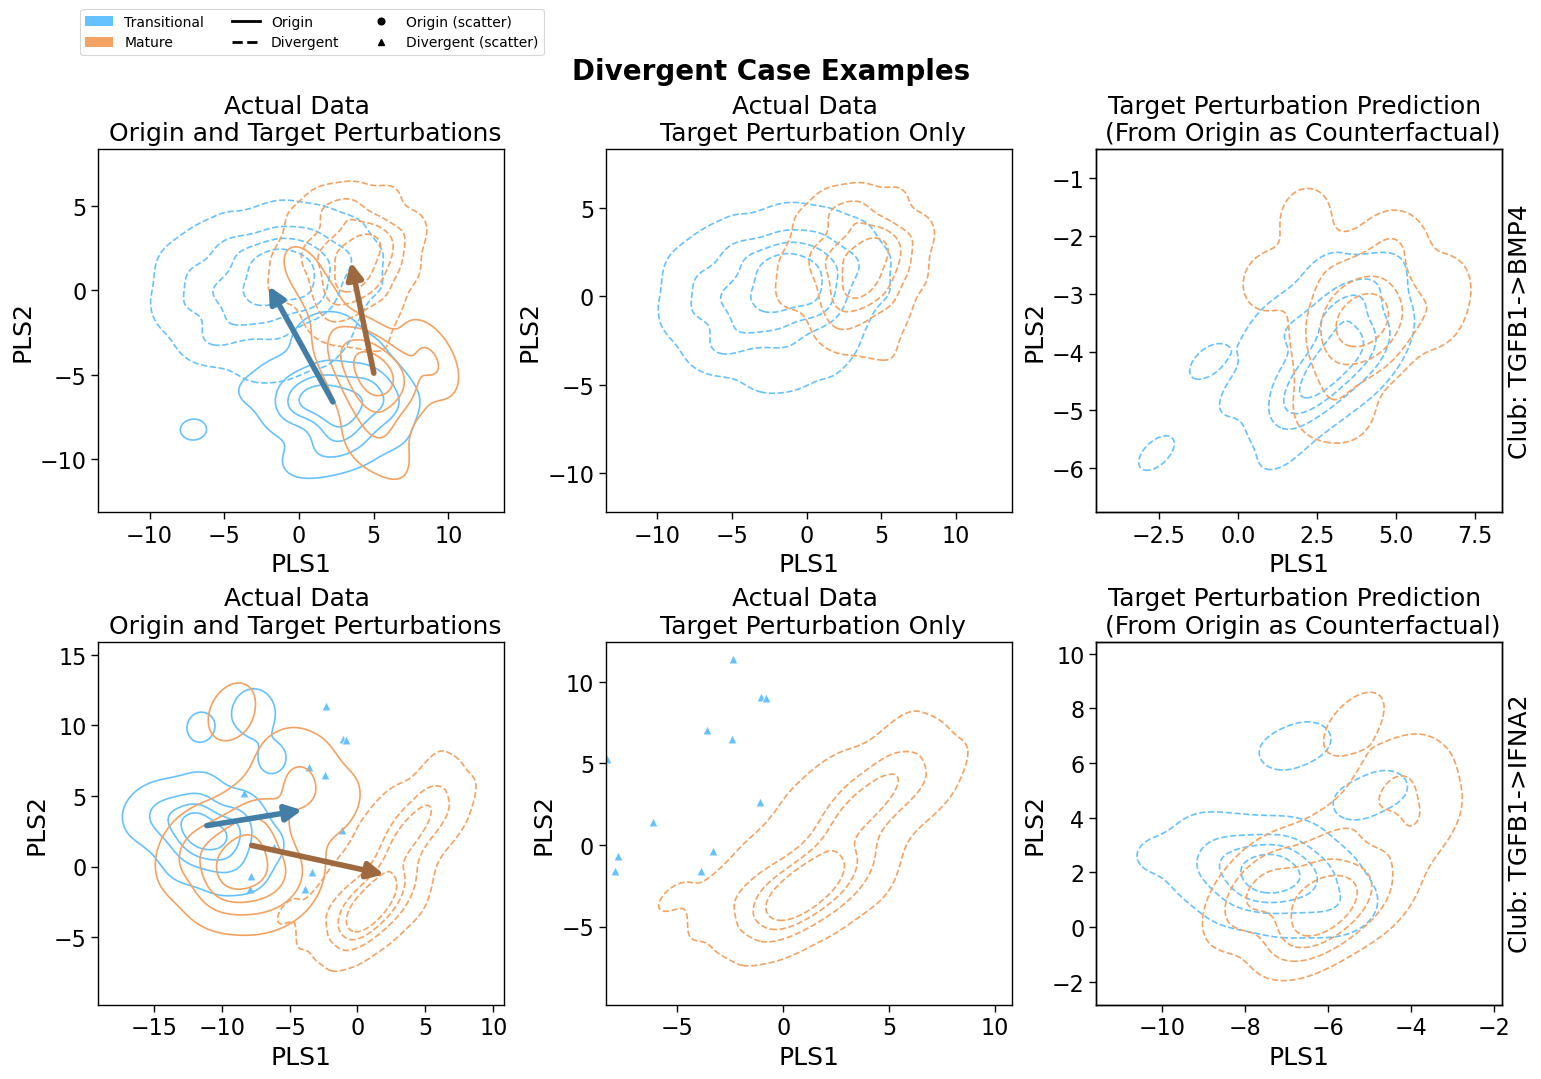

In [10]:
include_origin_actual = False
divergent_conds = [
    'Club^TGFB1->BMP4', 
    'Club^TGFB1->IFNA2', 
]

nrows = len(divergent_conds)
ncols = 3

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows), 
                       constrained_layout = True)
ax = np.atleast_2d(ax)

for (i,cond_label) in enumerate(divergent_conds):
    ct, perts = cond_label.split('^')
    origin_pert, target_pert = perts.split('->')
    
    tf_adata_actual, tf_adata_predicted = get_substype_prediction(
        ct = ct,
        origin_pert = origin_pert ,
        target_pert = target_pert,
        include_origin_actual = include_origin_actual
    )
    
    
    # actual data, all 
    j = 0
    viz_df_actual = prep_viz_df(
        adata = tf_adata_actual.copy(), 
        viz_type = 'actual', 
        include_origin_actual = True
    )

    plot_panel(
        viz_df = viz_df_actual, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert, 
        display_vectors = True
    )
    ax[i,j].set_title('Actual Data \n Origin and Target Perturbations')


    j = 1
    viz_df_actual = viz_df_actual[viz_df_actual[pert_col] == target_pert].copy()
    plot_panel(
        viz_df = viz_df_actual, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert
    )
    ax[i,j].set_title('Actual Data \n Target Perturbation Only')


    j = 2
    viz_df_predicted = prep_viz_df(
        adata = tf_adata_predicted.copy(), 
        viz_type = 'prediction', 
        include_origin_actual = include_origin_actual
    )
    plot_panel(
        viz_df = viz_df_predicted, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert
    )
    ax[i,j].set_title('Target Perturbation Prediction \n (From Origin as Counterfactual)')


    ax_right = ax[i, j].twinx()
    ax_right.set_ylabel(cond_label.replace('^', ': '))
    ax_right.set_yticks([])

# add figure-level legend
for i in range(nrows):    
    for j in range(ncols):
        if (i,j) == (0,0):
            legend = ax[i,j].get_legend()
            handles = legend.legend_handles
            labels = [t.get_text() for t in legend.texts]

        ax[i,j].legend_.remove()
        
fig.legend(
    handles = handles,
    labels = labels,
    loc = 'upper center',
    ncol = 3,
    title = '', 
    bbox_to_anchor = (0.2, 1.05)
)
fig.suptitle('Divergent Case Examples', fontsize = 20, fontweight = 'bold')



Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.71it/s]


Get the predictions
Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.66it/s]


Get the predictions
Set up inputs for prediction


...

100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.44it/s]


Get the predictions
Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.55it/s]


Get the predictions


Text(0.5, 0.98, 'Convergent Case Examples')

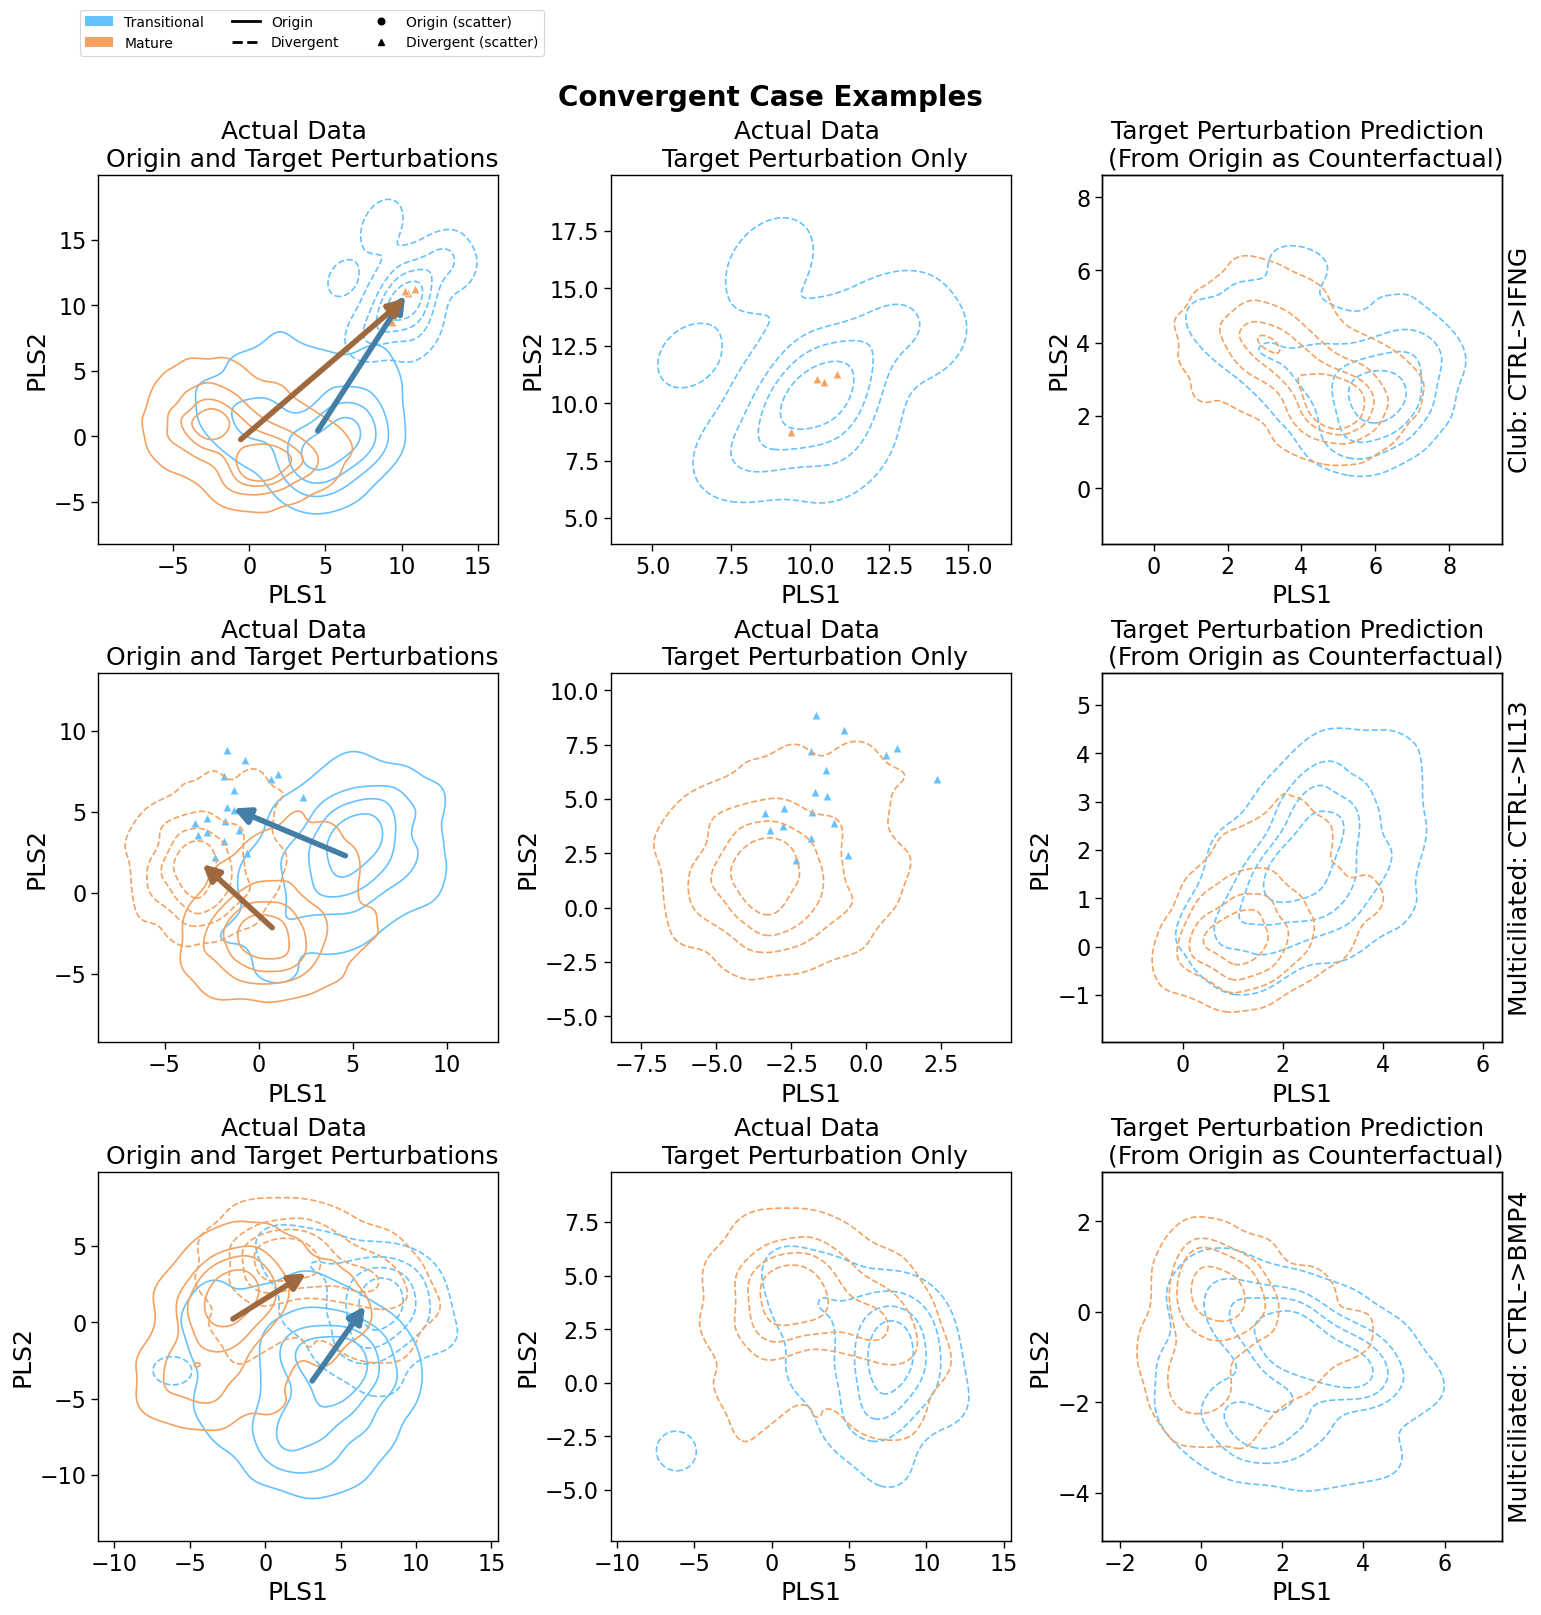

In [22]:
include_origin_actual = False
# convergent_conds = [
# #     'Club^IFNG->TGFB1',
#     'Multiciliated^CTRL->IL13', 
# ]


convergent_conds = [
    'Club^CTRL->IFNG',
    'Multiciliated^CTRL->IL13', 
    'Multiciliated^CTRL->BMP4', 
]

nrows = len(convergent_conds)
ncols = 3

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows), 
                       constrained_layout = True)
ax = np.atleast_2d(ax)

for (i,cond_label) in enumerate(convergent_conds):
    ct, perts = cond_label.split('^')
    origin_pert, target_pert = perts.split('->')
    
    tf_adata_actual, tf_adata_predicted = get_substype_prediction(
        ct = ct,
        origin_pert = origin_pert ,
        target_pert = target_pert,
        include_origin_actual = include_origin_actual
    )
    
    
    # actual data, all 
    j = 0
    viz_df_actual = prep_viz_df(
        adata = tf_adata_actual.copy(), 
        viz_type = 'actual', 
        include_origin_actual = True
    )

    plot_panel(
        viz_df = viz_df_actual, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert, 
        display_vectors = True
    )
    ax[i,j].set_title('Actual Data \n Origin and Target Perturbations')


    j = 1
    viz_df_actual = viz_df_actual[viz_df_actual[pert_col] == target_pert].copy()
    plot_panel(
        viz_df = viz_df_actual, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert
    )
    ax[i,j].set_title('Actual Data \n Target Perturbation Only')


    j = 2
    viz_df_predicted = prep_viz_df(
        adata = tf_adata_predicted.copy(), 
        viz_type = 'prediction', 
        include_origin_actual = include_origin_actual
    )
    plot_panel(
        viz_df = viz_df_predicted, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert
    )
    ax[i,j].set_title('Target Perturbation Prediction \n (From Origin as Counterfactual)')


    ax_right = ax[i, j].twinx()
    ax_right.set_ylabel(cond_label.replace('^', ': '))
    ax_right.set_yticks([])

# add figure-level legend
for i in range(nrows):    
    for j in range(ncols):
        if (i,j) == (0,0):
            legend = ax[i,j].get_legend()
            handles = legend.legend_handles
            labels = [t.get_text() for t in legend.texts]

        ax[i,j].legend_.remove()
        
fig.legend(
    handles = handles,
    labels = labels,
    loc = 'upper center',
    ncol = 3,
    title = '', 
    bbox_to_anchor = (0.2, 1.05)
)
fig.suptitle('Convergent Case Examples', fontsize = 20, fontweight = 'bold')


Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.01it/s]


Get the predictions
Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.19it/s]


Get the predictions
Set up inputs for prediction


...

100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.25it/s]


Get the predictions
Set up inputs for prediction


100%|████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.12it/s]


Get the predictions


Text(0.5, 0.98, 'Parallel Case Examples')

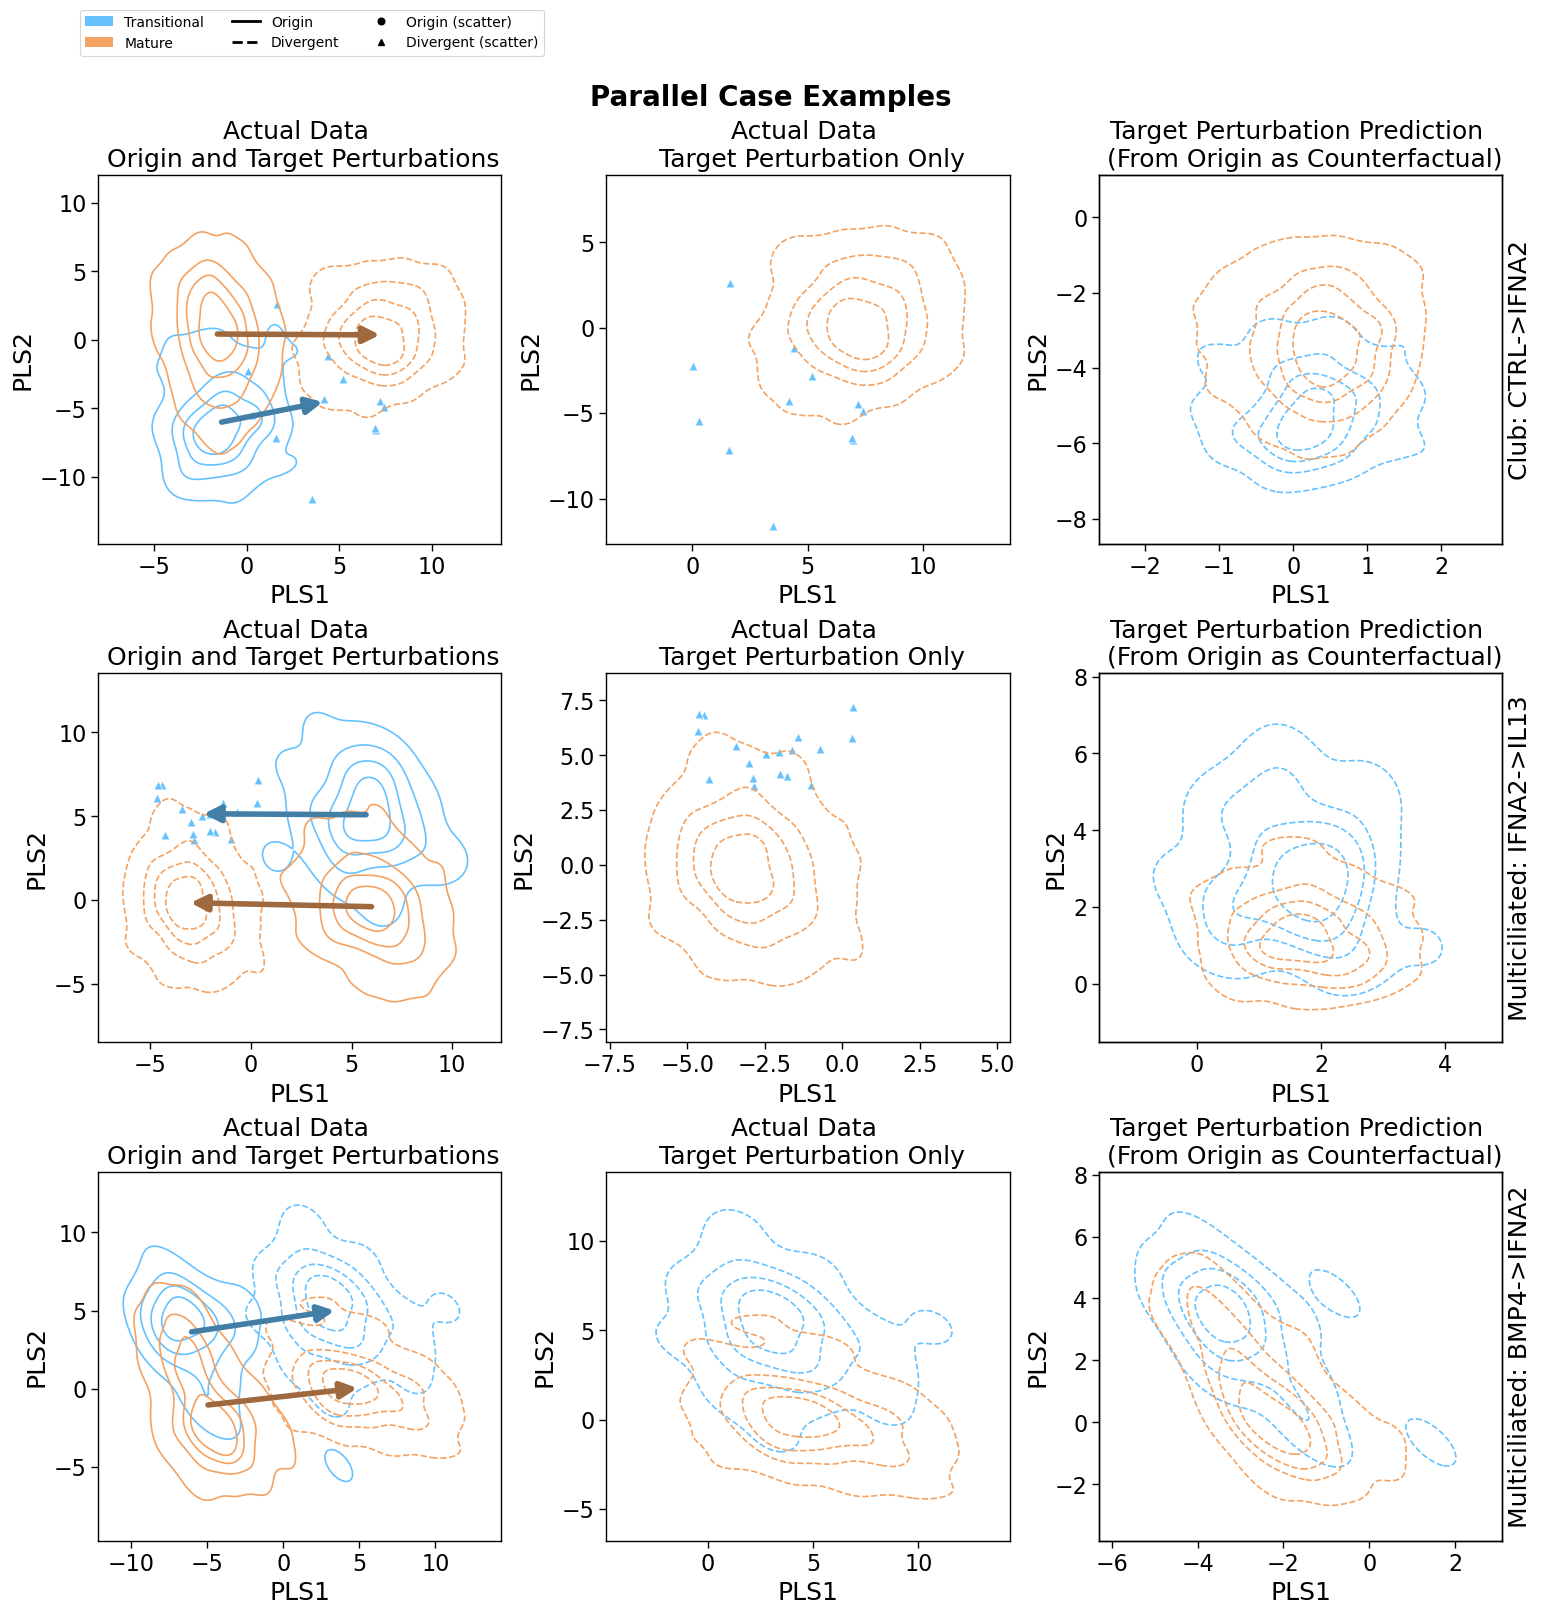

In [25]:
include_origin_actual = False
parallel_conds = [
    'Club^CTRL->IFNA2',
    'Multiciliated^IFNA2->IL13', 
    'Multiciliated^BMP4->IFNA2'
]

nrows = len(parallel_conds)
ncols = 3

fig, ax = plt.subplots(ncols = ncols, nrows = nrows, figsize = (5.1*ncols, 5.1*nrows), 
                       constrained_layout = True)
ax = np.atleast_2d(ax)

for (i,cond_label) in enumerate(parallel_conds):
    ct, perts = cond_label.split('^')
    origin_pert, target_pert = perts.split('->')
    
    tf_adata_actual, tf_adata_predicted = get_substype_prediction(
        ct = ct,
        origin_pert = origin_pert ,
        target_pert = target_pert,
        include_origin_actual = include_origin_actual
    )
    
    
    # actual data, all 
    j = 0
    viz_df_actual = prep_viz_df(
        adata = tf_adata_actual.copy(), 
        viz_type = 'actual', 
        include_origin_actual = True
    )

    plot_panel(
        viz_df = viz_df_actual, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert, 
        display_vectors = True
    )
    ax[i,j].set_title('Actual Data \n Origin and Target Perturbations')


    j = 1
    viz_df_actual = viz_df_actual[viz_df_actual[pert_col] == target_pert].copy()
    plot_panel(
        viz_df = viz_df_actual, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert
    )
    ax[i,j].set_title('Actual Data \n Target Perturbation Only')


    j = 2
    viz_df_predicted = prep_viz_df(
        adata = tf_adata_predicted.copy(), 
        viz_type = 'prediction', 
        include_origin_actual = include_origin_actual
    )
    plot_panel(
        viz_df = viz_df_predicted, 
        ax = ax[i,j], 
        cond_ = cond_label, n_scatter = 25, origin_pert = origin_pert
    )
    ax[i,j].set_title('Target Perturbation Prediction \n (From Origin as Counterfactual)')


    ax_right = ax[i, j].twinx()
    ax_right.set_ylabel(cond_label.replace('^', ': '))
    ax_right.set_yticks([])

# add figure-level legend
for i in range(nrows):    
    for j in range(ncols):
        if (i,j) == (0,0):
            legend = ax[i,j].get_legend()
            handles = legend.legend_handles
            labels = [t.get_text() for t in legend.texts]

        ax[i,j].legend_.remove()
        
fig.legend(
    handles = handles,
    labels = labels,
    loc = 'upper center',
    ncol = 3,
    title = '', 
    bbox_to_anchor = (0.2, 1.05)
)
fig.suptitle('Parallel Case Examples', fontsize = 20, fontweight = 'bold')


1) Visually, we see that subtype heterogeneity of predictions is maintained regardless of the type of perturbation shift type. In instances of total collape in the convergent case (Control --> IFNG), we see that the KDEs are nearly overlapping.  